# Business Understanding

The purpose of this project is to develop a deep learning system capable of automatically detecting plant diseases from images of plant leaves. Plant diseases are a major challenge in agriculture because they can significantly reduce crop yield and quality if not identified early. Many farmers rely on manual inspection or expert consultation to diagnose plant diseases, which can be expensive.

This project aims to use computer vision and deep learning techniques to create a model that can classify plant leaf images into different disease categories. By automating disease detection, the solution can assist farmers and agricultural experts in identifying plant diseases quickly and accurately.

### Stakeholders

Several groups could benefit from this system:

* **Agricultural organizations and researchers** – who may use such models to monitor crop health and improve disease management strategies.
* **Farmers** – who need quick and reliable ways to identify plant diseases in their crops.
* **Agricultural experts and agronomists** – who can use the system as a diagnostic support tool.
* **Technology developers** – who could integrate the model into mobile or web-based agricultural tools.

### Business Problem

The main problem addressed in this project is the difficulty of early and accurate plant disease identification. Delays in disease detection can lead to significant crop losses and economic impact for farmers. By building a machine learning model that can detect diseases from leaf images, the project aims to provide a scalable and accessible solution for disease diagnosis.

### Scope of the Project

The scope of this project includes:

* Building image classification models to identify plant diseases from leaf images.
* Training and evaluating two deep learning models: a **Custom Convolutional Neural Network (CNN)** and a **MobileNetV2 transfer learning model**.


### Data Sources

The project uses an image dataset containing labeled plant leaf images representing healthy plants and various disease classes. These images are used to train and evaluate the deep learning models.

### Expected Outcome

The expected outcome of this project is a trained model capable of accurately classifying plant diseases from images. The model can later be deployed in an application that allows users to upload a plant leaf image and receive a predicted disease category, helping support faster agricultural decision-making.


In [1]:
# import relevant libraries

import os
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import classification_report, confusion_matrix
import hashlib
from PIL import Image
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau



## Loading Training & Validation Images

In [2]:
# Base directory
base_dir = "./plant_dataset"

# Load training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=f"{base_dir}/train",
    image_size=(128,128),
    batch_size=32,
    labels="inferred",
    label_mode="categorical", # one-hot encode labels
    color_mode="rgb",
    shuffle=True
)

# Load validation dataset
val_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=f"{base_dir}/val",
    image_size=(128,128),
    batch_size=32,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    shuffle=True
)

# Load test dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=f"{base_dir}/test",
    image_size=(128,128),
    batch_size=32,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    shuffle=False
)
class_names = train_dataset.class_names  
num_classes = len(class_names)

print("Number of classes:", num_classes)

# Print dataset sizes
print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Found 33 files belonging to 1 classes.
Number of classes: 38
Training batches: 2197
Validation batches: 550
Test batches: 2


In [3]:
# Top 5 images per class
print("Train classes:", os.listdir("./plant_dataset/train")[:5])
print("Val classes:", os.listdir("./plant_dataset/val")[:5])
print("Test classes:", os.listdir("./plant_dataset/test")[:5])

Train classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
Val classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
Test classes: ['all_test_images']


In [4]:
# Check number of classes and plant names
print("Number of classes:", len(train_dataset.class_names))
print("\nClass indices:\n")
for index, class_name in enumerate(train_dataset.class_names):
    print(index, ":", class_name)

Number of classes: 38

Class indices:

0 : Apple___Apple_scab
1 : Apple___Black_rot
2 : Apple___Cedar_apple_rust
3 : Apple___healthy
4 : Blueberry___healthy
5 : Cherry_(including_sour)___Powdery_mildew
6 : Cherry_(including_sour)___healthy
7 : Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 : Corn_(maize)___Common_rust_
9 : Corn_(maize)___Northern_Leaf_Blight
10 : Corn_(maize)___healthy
11 : Grape___Black_rot
12 : Grape___Esca_(Black_Measles)
13 : Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 : Grape___healthy
15 : Orange___Haunglongbing_(Citrus_greening)
16 : Peach___Bacterial_spot
17 : Peach___healthy
18 : Pepper,_bell___Bacterial_spot
19 : Pepper,_bell___healthy
20 : Potato___Early_blight
21 : Potato___Late_blight
22 : Potato___healthy
23 : Raspberry___healthy
24 : Soybean___healthy
25 : Squash___Powdery_mildew
26 : Strawberry___Leaf_scorch
27 : Strawberry___healthy
28 : Tomato___Bacterial_spot
29 : Tomato___Early_blight
30 : Tomato___Late_blight
31 : Tomato___Leaf_Mold
32 : To

* 38 total number of classes observed in training dataset

## Checking for Class Distribution if the number of images are balanced across the classes

In [5]:
# Create a dictionary to hold counts
class_counts = {}

# Iterate through the dataset
for images, labels in train_dataset:
    # labels are one-hot encoded, convert to class index
    class_indices = tf.argmax(labels, axis=1).numpy()
    for idx in class_indices:
        class_counts[idx] = class_counts.get(idx, 0) + 1

# Map indices back to class names
class_names = train_dataset.class_names  # this exists in the tf.data.Dataset object
for idx, count in class_counts.items():
    print(f"{class_names[idx]} : {count}")

Potato___Late_blight : 1939
Tomato___Leaf_Mold : 1882
Squash___Powdery_mildew : 1736
Soybean___healthy : 2022
Tomato___Late_blight : 1851
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 1642
Tomato___Target_Spot : 1827
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 1722
Tomato___healthy : 1926
Strawberry___healthy : 1824
Tomato___Bacterial_spot : 1702
Apple___healthy : 2008
Potato___healthy : 1824
Corn_(maize)___Northern_Leaf_Blight : 1908
Apple___Apple_scab : 2016
Raspberry___healthy : 1781
Tomato___Spider_mites Two-spotted_spider_mite : 1741
Cherry_(including_sour)___healthy : 1826
Blueberry___healthy : 1816
Cherry_(including_sour)___Powdery_mildew : 1683
Apple___Black_rot : 1987
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 1961
Peach___Bacterial_spot : 1838
Tomato___Tomato_mosaic_virus : 1790
Peach___healthy : 1728
Pepper,_bell___Bacterial_spot : 1913
Tomato___Septoria_leaf_spot : 1745
Potato___Early_blight : 1939
Corn_(maize)___healthy : 1859
Grape___Esca_(Black_Measles) : 1920
Corn

## Observation
* **The dataset is well distributed across the classes, no severe skew hence no need for oversampling.**

## Check for corrupt images

In [6]:

splits = ["train", "val", "test"]
base_path = "./plant_dataset"

corrupted_images = []

for split in splits:
    split_path = os.path.join(base_path, split)
    
    # Loop through each class folder in the split
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if not os.path.isdir(class_path):
            continue
        
        # Loop through all images in the class folder
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()  # Verify integrity
            except Exception:
                corrupted_images.append(img_path)

print(f"Total corrupted images found: {len(corrupted_images)}")
if corrupted_images:
    print("Some images are corrupted. Example:")
    print(corrupted_images[:5])
else:
    print("No corrupted images found.")

Total corrupted images found: 0
No corrupted images found.



* **No corrupted images found.**

## Data Augmentation to training dataset

In [7]:
# Data augmentation improves generalization
data_augmentation = tf.keras.Sequential([                 
    layers.RandomFlip("horizontal_and_vertical"),    # Random Flip
    layers.RandomRotation(0.1),                     # Randomly rotates images by a fraction of 0.1, Prevents the model from overfitting to one fixed orientation
    layers.RandomZoom(0.1),                         # Random Zoom
])

# apply augmentation on the training dataset
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(x), y))


## **CNN Model**

In [8]:

model = Sequential([
    data_augmentation,                          
    layers.Rescaling(1./255),                 

    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    MaxPooling2D((2,2)),
    BatchNormalization(),             # normalization to improve the model stability & performance, and fasten training
    
    # Conv Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    BatchNormalization(),
    
    # Conv Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),    # ReLU Introduces Non-Linearity, fasten training, and reduces vanishing gradient problem
    MaxPooling2D((2,2)),
    BatchNormalization(),
    
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),  
    Dropout(0.5),                  #  Dropout regularization to reduce overfitting
    Dense(num_classes, activation='softmax') # activation set to softmax in last layer because we're handling a "multi-class" classification problem.
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),  # Adam optimizer to improve training by enabling the model to learn faster and more efficiently through adaptive learning rates
    loss='categorical_crossentropy', # categorical_crossentropy loss function for multi-class classification problems.
    metrics=['accuracy']
)

model.summary()

C:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ ?                           │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Callbacks

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True)

# Save the best model automatically
checkpoint = ModelCheckpoint(
    "cnn_model.keras",
    monitor='val_loss', 
    save_best_only=True,
    verbose=1)

# Reduce learning rate if the validation metric stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3)

## Training cnn model

In [10]:
history = model.fit(
    train_dataset,  
    validation_data=val_dataset,
    epochs=10,                
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.3420 - loss: 2.4933
Epoch 1: val_loss improved from None to 1.46487, saving model to cnn_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1655s 743ms/step - accuracy: 0.4642 - loss: 1.9541 - val_accuracy: 0.5710 - val_loss: 1.4649 - learning_rate: 1.0000e-04
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.6402 - loss: 1.2131
Epoch 2: val_loss did not improve from 1.46487
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1639s 746ms/step - accuracy: 0.6687 - loss: 1.1129 - val_accuracy: 0.4781 - val_loss: 1.8611 - learning_rate: 1.0000e-04
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7396 - loss: 0.8682
Epoch 3: val_loss did not improve from 1.46487
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2742s 1s/step - accuracy: 0.7517 - loss: 0.8238 - val_accuracy: 0.5534 - val_loss: 1.6532 - learning_rate: 1.0000e-04
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.7870 - loss: 0.7010
Epoch 4: val_lo

In [11]:
# Save the model
model.save("cnn_model.keras")

## Cnn training history

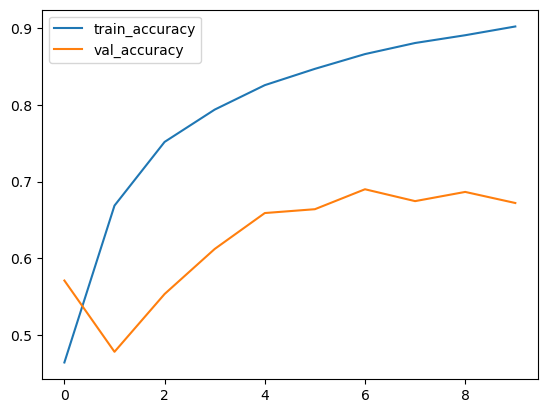

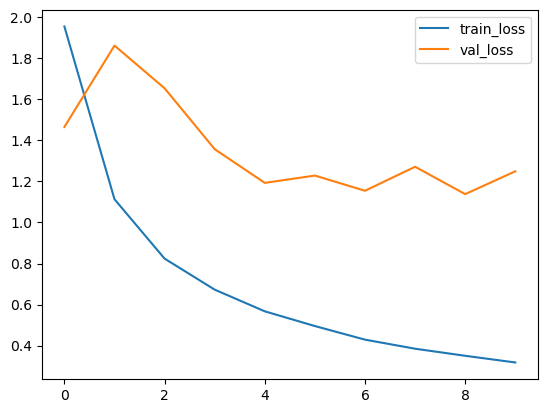

In [12]:
# Accuracy
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

## **TRANSFER LEARNING (MobileNetV2)**

In [23]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (128, 128)
NUM_CLASSES = 38  # from your dataset

# Load MobileNetV2 without top layers, pre-trained on ImageNet
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base_model
base_model.trainable = False

# Add custom classification head
inputs = tf.keras.Input(shape=(128,128,3))
x = preprocess_input(inputs)                  # Preprocessing 
x = base_model(x, training=False)             
x = layers.GlobalAveragePooling2D()(x)       # Pool features
x = layers.Dropout(0.3)(x)                    # Dropout for regularization
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_tl = tf.keras.Model(inputs, outputs)

In [24]:
# Compile the transfer learning model
model_tl.compile(
    optimizer=Adam(learning_rate=0.0001),   
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
# callbacks
checkpoint2 = ModelCheckpoint(
    "mobilenetv2.keras",
    monitor='val_loss', 
    save_best_only=True,
    verbose=1)

## Training MobileNetV2 model

In [26]:
history_tl = model_tl.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[early_stop, checkpoint2, reduce_lr]
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.4223 - loss: 2.2295
Epoch 1: val_loss improved from None to 0.52572, saving model to mobilenetv2.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 956s 421ms/step - accuracy: 0.6309 - loss: 1.3815 - val_accuracy: 0.8704 - val_loss: 0.5257 - learning_rate: 1.0000e-04
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.8457 - loss: 0.5536
Epoch 2: val_loss improved from 0.52572 to 0.33752, saving model to mobilenetv2.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 850s 387ms/step - accuracy: 0.8574 - loss: 0.5017 - val_accuracy: 0.9085 - val_loss: 0.3375 - learning_rate: 1.0000e-04
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.8902 - loss: 0.3819
Epoch 3: val_loss improved from 0.33752 to 0.26682, saving model to mobilenetv2.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 829s 377ms/step - accuracy: 0.8941 - loss: 0.3622 - val_accuracy: 0.9255 - val_loss: 0.2668 - learning_rate: 1.0000e-04
Epoch 4/10
2197/2197 ━

In [28]:
# Save the model
model.save('mobilenetv2.keras')

## MobileNetV2 training history

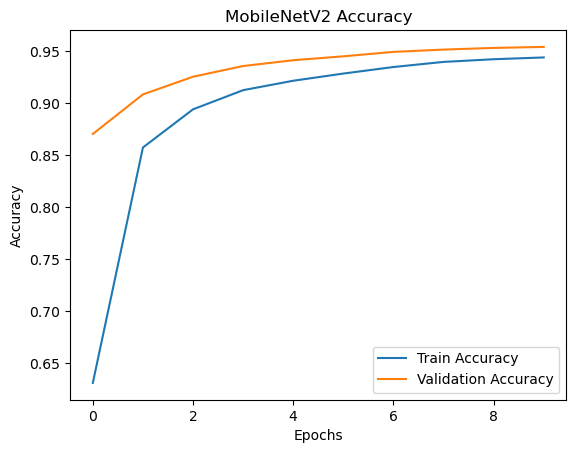

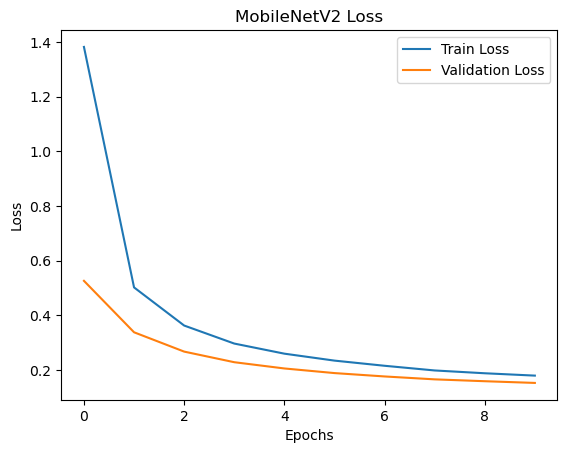

In [34]:

# Accuracy
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history_tl.history['loss'], label='Train Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

* The MobileNetV2 model achieved high training and validation accuracy with decreasing loss, showing strong classification performance. It is both accurate and generalizes well on validation data.

# **Final Model Selection**

The  **MobileNetV2** is selected as the final model for this project due to its higher accuracy, lower loss, and better overall performance in plant disease classification. It achieved approximately **94.4% training accuracy** and **95.4% validation accuracy**, with a **validation loss of about 0.152** by the final epoch. In comparison, the CNN model achieved  **90.0% training accuracy** but only **69.4% validation accuracy**, indicating weaker generalization to unseen data. 
